In [1]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np
from array import array
import pandas as pd


def single_event(file_address, entry_index, num_channels):
    file = ROOT.TFile(file_address)

    mytree = file.Get("tree")

    branches = mytree.GetListOfBranches()

    for branch in branches:
        print(branch.GetName())

    mytree.SetBranchStatus("waveform_samples", 1)
    raw_wf = array('f', [0]*(len(mytree.waveform_samples)-1))
    mytree.SetBranchAddress("waveform_samples", raw_wf)

    num_events = int(mytree.GetEntries()/num_channels)

    df = pd.DataFrame()

    fig, ax = plt.subplots(figsize=(12, 7))
    for i in range(num_channels):
        mytree.GetEntry(entry_index + i*num_events)
        #wfarray = np.random.random(len(mytree.waveform_samples))
        wfarray = raw_wf
        #print("wfarray length is: ", len(wfarray))
        column_name = f"ch{mytree.channel}"
        df[column_name] = wfarray
        plt.plot(raw_wf)
        plt.grid()

    print(df.head())
    return df

event_id
timestamp
channel
resolution
numberOfSamples
waveform_samples
    ch30   ch31    ch32       ch33       ch34       ch35       ch36  \
0  2.325  2.077 -15.066 -55.924000  46.004002 -18.104000  35.773998   
1  2.232  1.860 -15.159 -56.078999  45.910999 -18.259001  35.929001   
2  2.170  1.829 -15.283 -55.986000  45.786999 -18.351999  35.712002   
3  2.201  1.643 -15.035 -55.924000  46.035000 -18.351999  35.588001   
4  2.387  2.077 -15.221 -55.862000  46.066002 -18.476000  35.805000   

        ch37    ch38       ch39  ...       ch54    ch55       ch56       ch57  \
0 -34.937000 -11.501 -44.980999  ...  48.949001 -14.446 -64.387001 -35.091999   
1 -34.905998 -11.377 -45.074001  ...  48.701000 -14.539 -64.293999 -35.278000   
2 -35.029999 -11.501 -44.826000  ...  48.980000 -14.477 -64.324997 -35.153999   
3 -35.029999 -11.315 -44.639999  ...  49.166000 -14.322 -64.045998 -35.247002   
4 -34.937000 -11.563 -44.423000  ...  49.104000 -14.384 -64.356003 -35.402000   

        ch58   

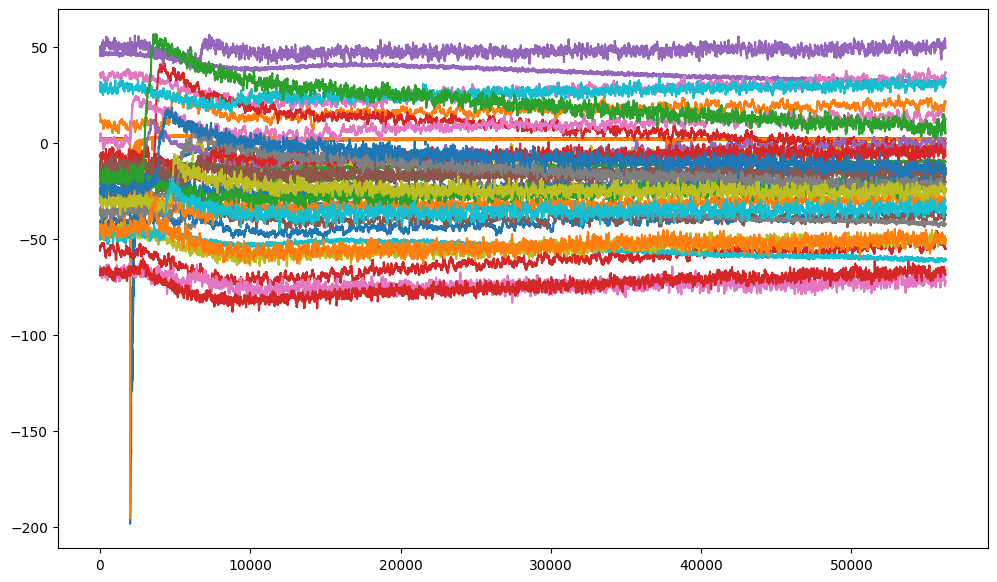

In [2]:
entry_ID = 9483
file_address = "/home/jiancheng/NAS/LAr_TPC_runs/Run26/LArComboFullDrift_Run26_EmmaTile_FilteredLAr0_90Deg_AnodeMeshV2_34chans_09052024/LArComboFullDrift_Run26_EmmaTile_FilteredLAr0_90Deg_AnodeMeshV2_34chans_09052024_dig2-usb51054_20240905161846-09.root"
event_data = single_event(file_address=file_address, entry_index=entry_ID, num_channels=34)

In [3]:
def baseline_correction(baseline_array, pretrigger = 1875 , correction = 0):
    avg = np.average(baseline_array[0:pretrigger])
    #print("first ", pretrigger, " samples has an average:", avg, "mV")
    corrected = np.array(baseline_array) - avg
    return corrected

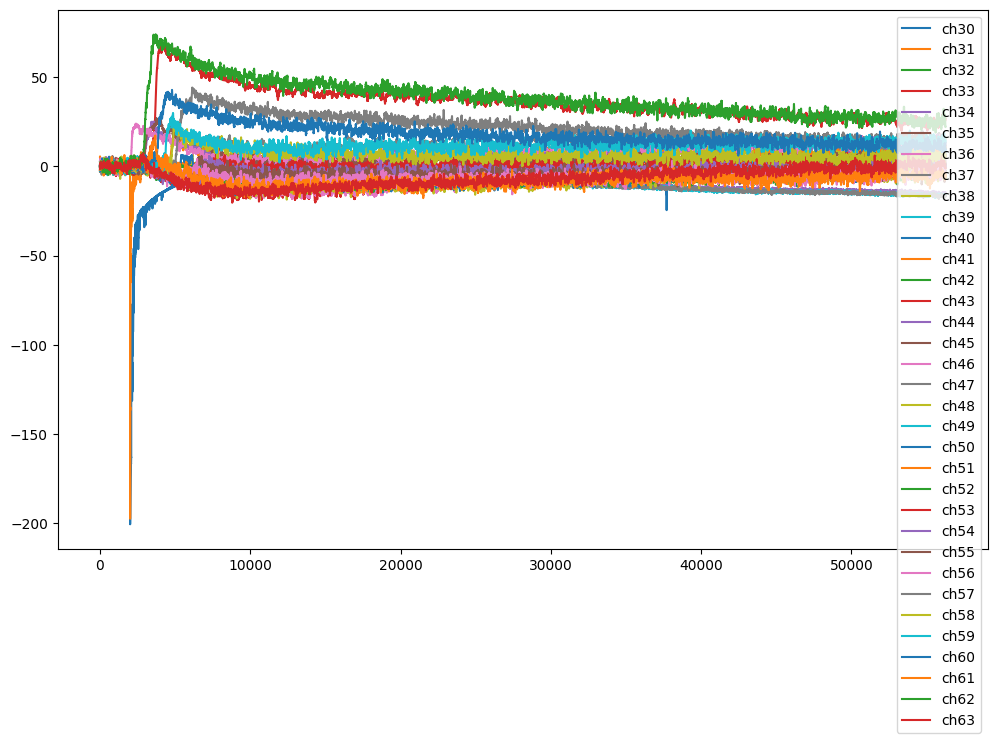

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

RMS_data = []
for i in range(34):
    ch_array = event_data[f'ch{i+30}']
    #print(ch_array[1800:2200])
    corrected_array = baseline_correction(baseline_array = event_data[f'ch{i+30}'].to_numpy())
    #print(len(corrected_array))
    plt.plot(corrected_array, label=f'ch{i+30}')
    plt.grid()
    plt.legend()
    event_data[f'ch{i+30}'] = corrected_array





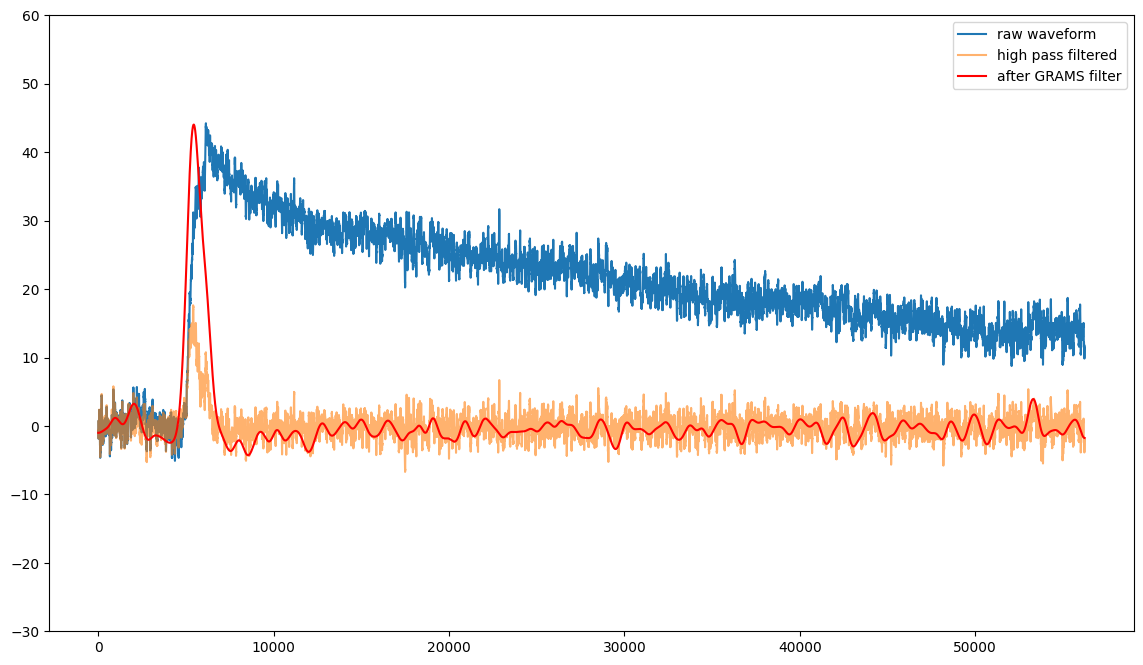

In [5]:
from scipy.signal import butter, lfilter
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm

temp_corrected_array = baseline_correction(baseline_array = event_data['ch52'].to_numpy())

def GRAMS_shaper_trial_1(raw_waveform, filter_order, critical_frequency, gaussian_sigma, gain, shaping_time=5, sampling_rate=125):
    b, a = butter(filter_order, critical_frequency, 'high')
    #plt.plot(raw_waveform, alpha = 0.7, label = 'original')
    high_pass_filtered = lfilter(b, a, raw_waveform)
    plt.plot(high_pass_filtered, alpha = 0.6, label = 'high pass filtered')
    
    # This is for lifting baseline, not trustworthy now
    #high_pass_filtered = (high_pass_filtered - np.min(high_pass_filtered)) / (np.max(high_pass_filtered) - np.min(high_pass_filtered)) * np.max(high_pass_filtered)

    # Gaussian filter
    gaussian_filtered = gaussian_filter1d(high_pass_filtered, sigma=gaussian_sigma)
    """
    if(np.max(gaussian_filtered)>3.5):
        gaussian_filtered = gaussian_filtered/np.max(gaussian_filtered)
    else:
        gaussian_filtered = 0.1*gaussian_filtered/np.max(gaussian_filtered)
    """

    # This is for generate a fake normal distribution, also not trustworthy
    """
    x = np.arange(0, len(gaussian_filtered))
    location = np.array(gaussian_filtered).argmax()  # Mean (μ)
    scale = shaping_time * sampling_rate
    # Calculate the PDF of the normal distribution
    pdf = gain * np.max(gaussian_filtered) * norm.pdf(x, loc=location, scale=scale)
    """
    return gaussian_filtered * gain

def GRAMS_high_pass(raw_waveform, filter_order, critical_frequency):
    b, a = butter(filter_order, critical_frequency, 'high')
    high_pass_filtered = lfilter(b, a, raw_waveform)
    return high_pass_filtered


plt.figure(figsize=(14, 8))
baseline_array = baseline_correction(baseline_array = event_data['ch57'].to_numpy())
plt.plot(baseline_array, label = 'raw waveform')
single_filtered_channel = GRAMS_shaper_trial_1(baseline_array, filter_order=1, critical_frequency=0.001, gaussian_sigma=250, shaping_time = 5, gain=4, sampling_rate=125)
#plt.xlim(1000, 12000)
plt.ylim(-30, 60)
plt.plot(single_filtered_channel, c='red', label='after GRAMS filter')
plt.legend()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


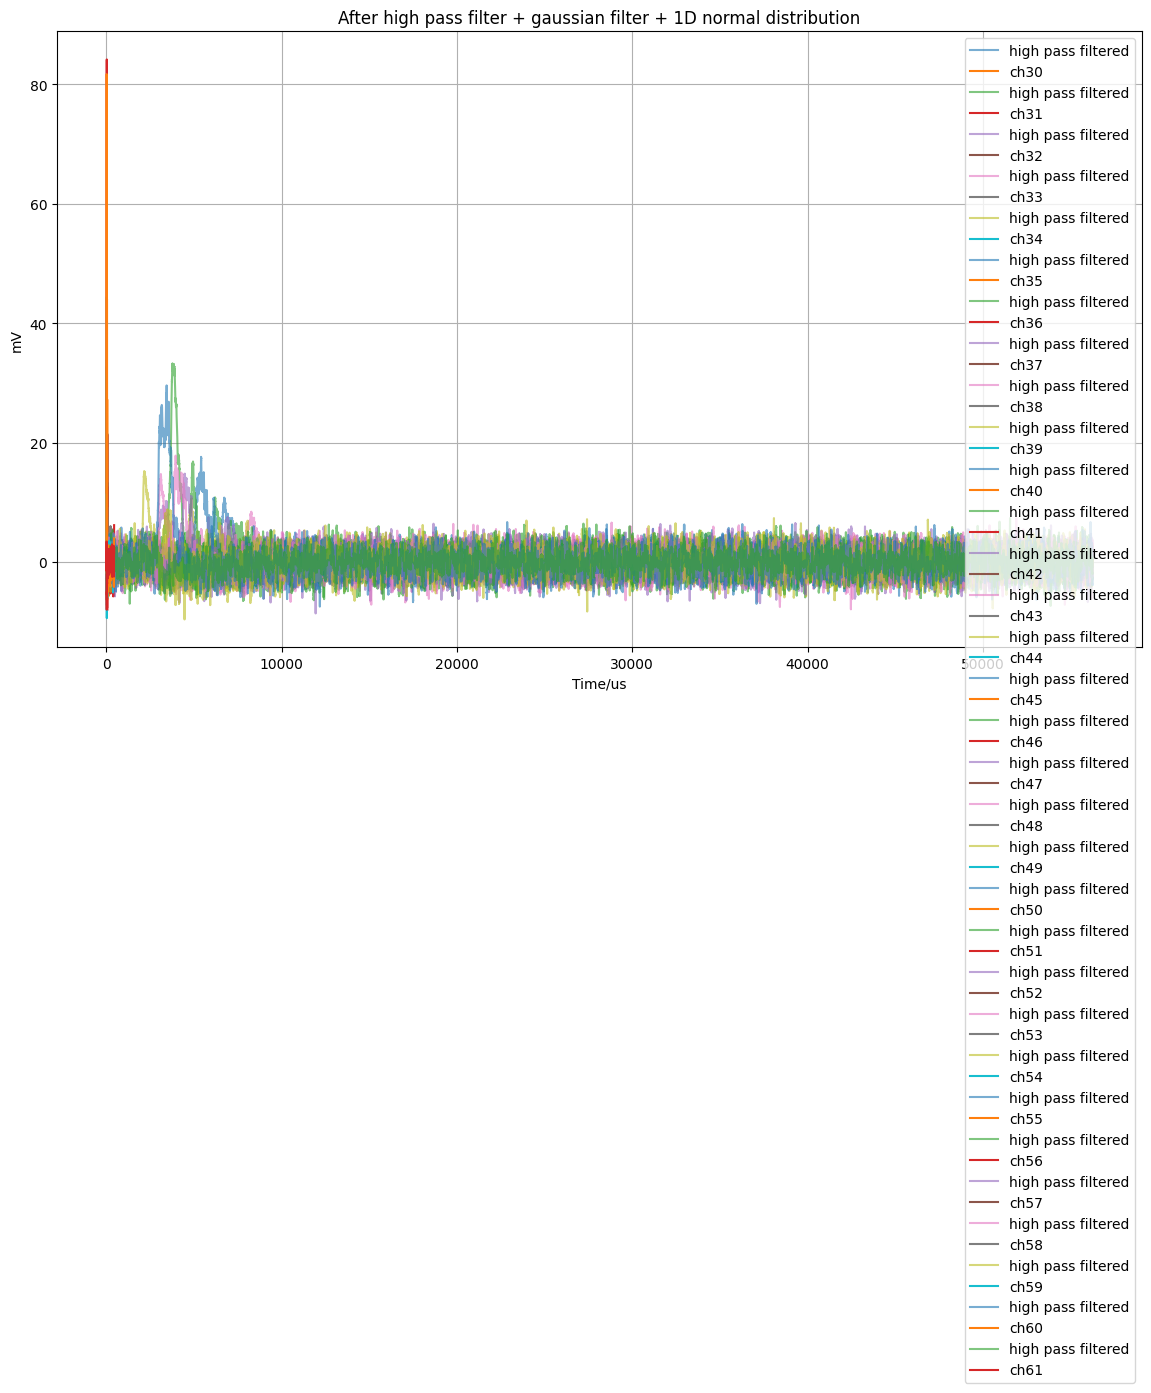

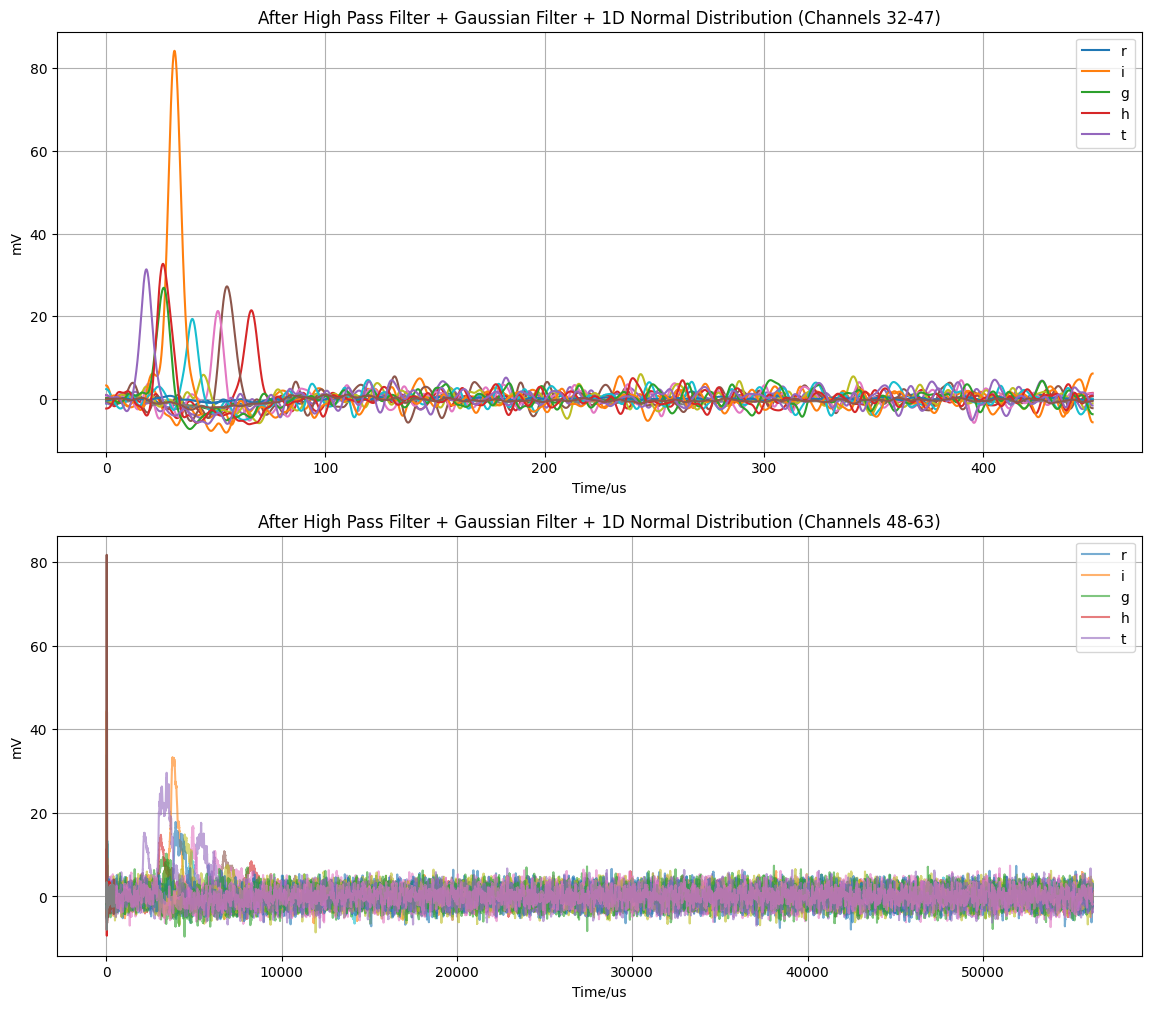

In [6]:
drift_time = np.arange(0, len(single_filtered_channel), 1) / 125

plt.figure(figsize=(14, 8))
for i in range(32):
    ch_array = event_data[f'ch{i+32}']
    #print(ch_array[1800:2200])
    baseline_array = baseline_correction(baseline_array = event_data[f'ch{i+32}'].to_numpy())
    corrected_array = GRAMS_shaper_trial_1(baseline_array, filter_order=1, critical_frequency=0.001, gaussian_sigma=250, gain=4)
    plt.plot(drift_time, corrected_array, label=f'ch{i+30}')
plt.grid()
plt.legend()
plt.ylabel("mV")
plt.xlabel("Time/us")
plt.title("After high pass filter + gaussian filter + 1D normal distribution")



# Create a figure with 2 subplots stacked vertically
fig, axs = plt.subplots(2, 1, figsize=(14, 12))

# First subplot for channels ch32 to ch47
for i in range(16):  # 16 channels from ch32 to ch47
    ch_array = event_data[f'ch{i+32}']
    baseline_array = baseline_correction(baseline_array=ch_array.to_numpy())
    corrected_array = GRAMS_shaper_trial_1(baseline_array, filter_order=1, critical_frequency=0.001, gaussian_sigma=250, gain=4)
    axs[0].plot(drift_time, corrected_array, label=f'ch{i+32}')  # Adjusted label for clarity

# Customizing the first subplot
axs[0].grid()
axs[0].legend("right")
axs[0].set_ylabel("mV")
axs[0].set_xlabel("Time/us")
axs[0].set_title("After High Pass Filter + Gaussian Filter + 1D Normal Distribution (Channels 32-47)")

# Second subplot for channels ch48 to ch63
for i in range(16):  # 16 channels from ch48 to ch63
    ch_array = event_data[f'ch{i+48}']
    baseline_array = baseline_correction(baseline_array=ch_array.to_numpy())
    corrected_array = GRAMS_shaper_trial_1(baseline_array, filter_order=1, critical_frequency=0.001, gaussian_sigma=250, gain=4)
    axs[1].plot(drift_time, corrected_array, label=f'ch{i+48}')  # Adjusted label for clarity

# Customizing the second subplot
axs[1].grid()
axs[1].legend("right")
axs[1].set_ylabel("mV")
axs[1].set_xlabel("Time/us")
axs[1].set_title("After High Pass Filter + Gaussian Filter + 1D Normal Distribution (Channels 48-63)")

# Adjust layout for better spacing
plt.show()


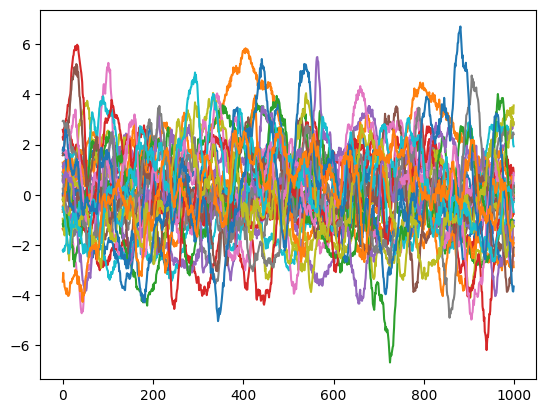

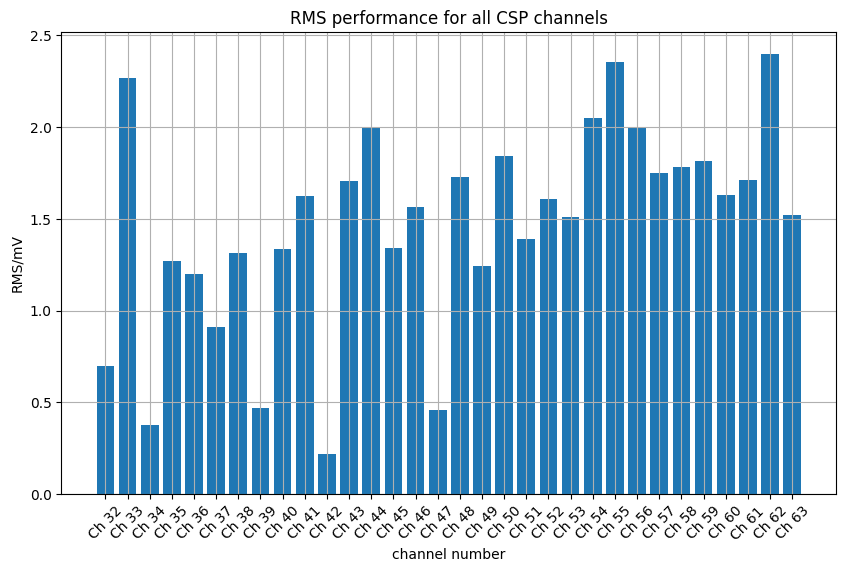

In [7]:

def GRAMS_RMS(baseline_array):
    """
    Calculate the Root Mean Square (RMS) of a given array.
    
    Parameters:
    arr (list or np.array): Input array of numerical values.
    
    Returns:
    float: The RMS value of the array.
    """
    baseline_array = np.array(baseline_array)  # Ensure input is a numpy array
    return np.sqrt(np.mean(baseline_array**2))


RMS_data = []
for i in range(32):
    ch_array = event_data[f'ch{i+32}']
    #print(ch_array[1800:2200])
    baseline_array = baseline_correction(baseline_array = event_data[f'ch{i+32}'].to_numpy())
    corrected_array = GRAMS_high_pass(baseline_array, filter_order=1, critical_frequency=0.001)
    plt.plot(corrected_array[len(corrected_array)-1000:len(corrected_array)])
    RMS_data.append(GRAMS_RMS(corrected_array[len(corrected_array)-1000:len(corrected_array)]))
    

# Create the bar plot
plt.figure(figsize=(10, 6))  # Set figure size
plt.bar(range(len(RMS_data)), RMS_data)  # Generate the bar plot
# Custom labels for x-axis (one for each element, can be any label like strings)
custom_labels = [f"Ch {i+32}" for i in range(len(RMS_data))]
# Customize x-axis ticks
plt.xticks(ticks=range(len(RMS_data)), labels=custom_labels, rotation=45, fontsize=10)  # Set custom labels, rotate, and adjust font size
plt.xlabel('channel number')  # Label for x-axis
plt.ylabel('RMS/mV')          # Label for y-axis
plt.title('RMS performance for all CSP channels')  # Plot title
plt.grid(True)  # Add grid lines to the plot
plt.show()  # Display the plot

/tmp/ipykernel_2287685/2222830355.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet', 40)


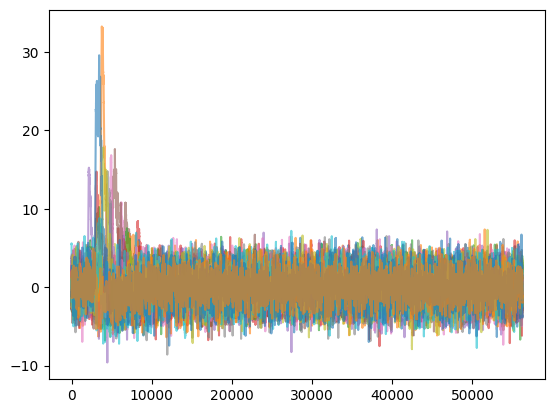

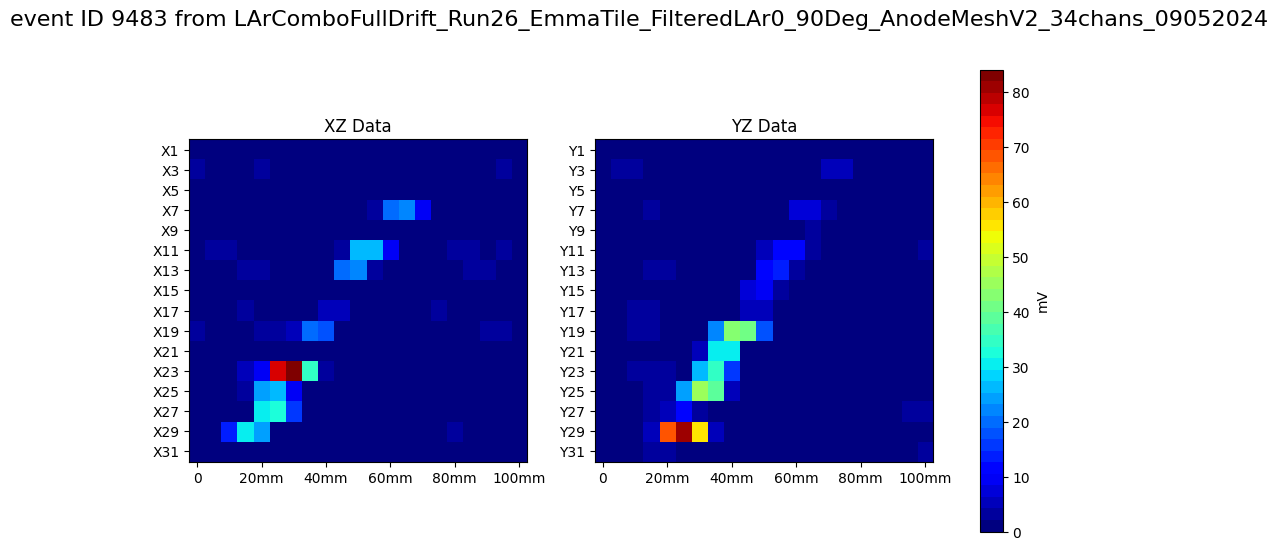

In [8]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# unit in mm
z = drift_time * 1
xz_data = []
x_max = []
yz_data = []
y_max = []

# for channels ch32 to ch47
for i in range(16):  # 16 channels from ch32 to ch47
    ch_array = event_data[f'ch{i+32}']
    baseline_array = baseline_correction(baseline_array=ch_array.to_numpy())
    corrected_array = GRAMS_shaper_trial_1(baseline_array, filter_order=1, critical_frequency=0.001, gaussian_sigma=250, gain=4)
    corrected_array = np.array(corrected_array[0:105*125])
    x_max.append(np.max(corrected_array))
    n_chunks = 21
    chunk_size = len(corrected_array) // n_chunks
    reshaped_array = corrected_array[:chunk_size * n_chunks].reshape(n_chunks, chunk_size)
    averaged_array = np.max(reshaped_array, axis=1)
    #plt.plot(averaged_array)
    #print(averaged_array)
    xz_data.append(averaged_array)

# for channels ch48 to ch63
for i in range(16):  # 16 channels from ch48 to ch63
    ch_array = event_data[f'ch{i+48}']
    baseline_array = baseline_correction(baseline_array=ch_array.to_numpy())
    corrected_array = GRAMS_shaper_trial_1(baseline_array, filter_order=1, critical_frequency=0.001, gaussian_sigma=250, gain=4)
    corrected_array = np.array(corrected_array[0:105*125])
    y_max.append(np.max(corrected_array))
    n_chunks = 21
    chunk_size = len(corrected_array) // n_chunks
    reshaped_array = corrected_array[:chunk_size * n_chunks].reshape(n_chunks, chunk_size)
    averaged_array = np.max(reshaped_array, axis=1)
    #plt.plot(averaged_array)
    #print(averaged_array)
    yz_data.append(averaged_array)



# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns, adjust figsize for aspect ratio

norm = mcolors.Normalize(vmin=0, vmax=np.max(xz_data))


# Plot the first data (xz_data) on the first subplot
cmap = cm.get_cmap('jet', 40) 
im1 = ax1.imshow(xz_data, cmap=cmap, norm=norm, aspect=20/16, interpolation='none')
ax1.set_title('XZ Data')

# Customize x and y ticks for the first subplot (XZ Data)
x_ticks_1 = [0, 4, 8, 12, 16, 20]  # X-axis positions for ticks
x_labels_1 = ['0', '20mm', '40mm', '60mm', '80mm', '100mm']  # X-axis labels

y_ticks_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]  # Y-axis positions for ticks
y_labels_1 = ['X1', 'X3', 'X5', 'X7', 'X9', 'X11', 'X13', 'X15', 'X17', 'X19', 'X21', 'X23', 'X25', 'X27', 'X29', 'X31']  # Y-axis labels

ax1.set_xticks(x_ticks_1)
ax1.set_xticklabels(x_labels_1)
ax1.set_yticks(y_ticks_1)
ax1.set_yticklabels(y_labels_1)


# Plot the second data (yz_data) on the second subplot
im2 = ax2.imshow(yz_data, cmap=cmap, norm=norm, aspect=20/16, interpolation='none')
ax2.set_title('YZ Data')

# Customize x and y ticks for the first subplot (XZ Data)
x_ticks_2 = [0, 4, 8, 12, 16, 20]  # X-axis positions for ticks
x_labels_2 = ['0', '20mm', '40mm', '60mm', '80mm', '100mm']  # X-axis labels

y_ticks_2 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]  # Y-axis positions for ticks
y_labels_2 = ['Y1', 'Y3', 'Y5', 'Y7', 'Y9', 'Y11', 'Y13', 'Y15', 'Y17', 'Y19', 'Y21', 'Y23', 'Y25', 'Y27', 'Y29', 'Y31']  # Y-axis labels

ax2.set_xticks(x_ticks_2)
ax2.set_xticklabels(x_labels_2)
ax2.set_yticks(y_ticks_2)
ax2.set_yticklabels(y_labels_2)

# Add a colorbar that spans both subplots
cbar = fig.colorbar(im1, ax=[ax1, ax2], orientation='vertical')
cbar.set_label('mV')

fig.suptitle(f'event ID {entry_ID} from LArComboFullDrift_Run26_EmmaTile_FilteredLAr0_90Deg_AnodeMeshV2_34chans_09052024', fontsize=16)

# Display the plot
plt.show()



[ 1.18471532  3.28727168  0.83565529 21.45875176  1.76697753 27.23442192
 21.2949106   1.22485209  5.86877756 19.37065191  0.78102135 84.17119794
 26.90587055 32.68785795 31.34904129  1.03120172]
[ 1.59112292  5.4880605   1.1440788   7.51552332  2.80992901 12.61667369
 13.30363112  9.16630534  4.99275441 44.03045324 30.58881066 33.89195716
 44.41875169 11.40535787 81.71013158  3.44556647]
[[1.88502771e+00 6.50178938e+00 1.35540769e+00 8.90375565e+00
  3.32896596e+00 1.49471667e+01 1.57610157e+01 1.08594624e+01
  5.91499266e+00 5.21635527e+01 3.62390327e+01 4.01523210e+01
  5.26235758e+01 1.35121022e+01 9.68032450e+01 4.08201540e+00]
 [5.23045332e+00 1.80407459e+01 3.76089786e+00 2.47055670e+01
  9.23700006e+00 4.14744342e+01 4.37326499e+01 3.01321360e+01
  1.64125402e+01 1.44740062e+02 1.00553731e+02 1.11412071e+02
  1.46016505e+02 3.74925099e+01 2.68603402e+02 1.13265131e+01]
 [1.32963028e+00 4.58612678e+00 9.56055503e-01 6.28038681e+00
  2.34813203e+00 1.05431901e+01 1.11172497e+01 7

/tmp/ipykernel_2287685/30210570.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet', 20)


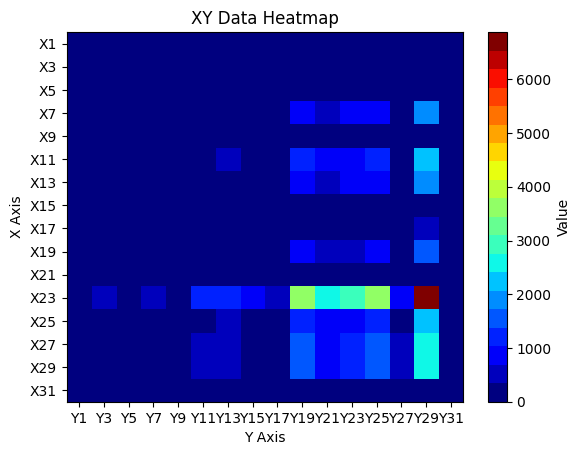

In [9]:
x_max = np.array(x_max)
y_max = np.array(y_max)
print(x_max)
print(y_max)
# Reshape xz_data to be a column vector and add it to yz_data (row vector)
xy_data = (x_max[:, np.newaxis]) * (y_max)
#xy_data = (2*(x_max[:, np.newaxis]) * (y_max))/(np.sqrt((x_max[:, np.newaxis]**2+y_max**2)))
#xy_data = np.maximum(x_max[:, np.newaxis], y_max)
print(xy_data)

# Normalize the color map to range from 0 to the max value in xy_data
norm = mcolors.Normalize(vmin=0, vmax=np.max(xy_data))

# Create a figure and axis
fig, ax = plt.subplots()

# Display the 2D array using imshow
cmap = cm.get_cmap('jet', 20) 
im = ax.imshow(xy_data, cmap=cmap, norm=norm, aspect='auto')  # 'aspect' can be adjusted

# Add a colorbar
cbar = fig.colorbar(im, ax=ax, label='Value')

# Customize X and Y ticks
x_ticks_xy = np.arange(16)  # Y-axis positions for ticks
x_labels_xy = ['Y1', 'Y3', 'Y5', 'Y7', 'Y9', 'Y11', 'Y13', 'Y15', 'Y17', 'Y19', 'Y21', 'Y23', 'Y25', 'Y27', 'Y29', 'Y31']  # Y-axis labels

y_ticks_xy = np.arange(16)  # X-axis positions for ticks
y_labels_xy = ['X1', 'X3', 'X5', 'X7', 'X9', 'X11', 'X13', 'X15', 'X17', 'X19', 'X21', 'X23', 'X25', 'X27', 'X29', 'X31']  # X-axis labels

# Set the ticks and labels
ax.set_xticks(x_ticks_xy)
ax.set_xticklabels(x_labels_xy)
ax.set_yticks(y_ticks_xy)
ax.set_yticklabels(y_labels_xy)

# Set titles and labels
plt.title('XY Data Heatmap')
plt.xlabel('Y Axis')
plt.ylabel('X Axis')

# Display the plot
plt.show()

now processing layer( 1 / 20 )	
now processing layer( 2 / 20 )	
now processing layer( 3 / 20 )	
now processing layer( 4 / 20 )	
now processing layer( 5 / 20 )	
now processing layer( 6 / 20 )	
now processing layer( 7 / 20 )	
now processing layer( 8 / 20 )	
now processing layer( 9 / 20 )	
now processing layer( 10 / 20 )	
now processing layer( 11 / 20 )	
now processing layer( 12 / 20 )	
now processing layer( 13 / 20 )	
now processing layer( 14 / 20 )	
now processing layer( 15 / 20 )	
now processing layer( 16 / 20 )	
now processing layer( 17 / 20 )	
now processing layer( 18 / 20 )	
now processing layer( 19 / 20 )	
now processing layer( 20 / 20 )	
[array([[  7.48304003,  15.81135263,   6.39048268,  12.23747376,
          6.35441799,  20.62998924,  10.25491479,  10.38640885,
         12.82193538,   9.82541585,   8.7008285 ,  13.01983372,
          9.43082073,   9.98749059,  14.99820876,  17.01545639],
       [ 21.83300233,  46.13222667,  18.64528624,  35.70484617,
         18.54006157,  60.1

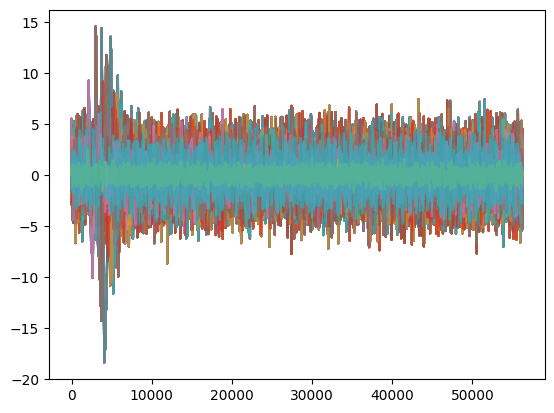

In [10]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

data_3D = []
TPC_length = 100    # mm
spatial_resolution = 5    #mm


for i in range(int(TPC_length/spatial_resolution)):
    max_x = []
    max_y = []
    for j in range(16):
        ch_array_x = event_data[f'ch{j+32}']
        ch_array_y = event_data[f'ch{j+48}']
        corrected_array_x = GRAMS_shaper_trial_1(ch_array_x, filter_order=4, critical_frequency=0.001, gaussian_sigma=150, gain=4)
        corrected_array_y = GRAMS_shaper_trial_1(ch_array_y, filter_order=4, critical_frequency=0.001, gaussian_sigma=150, gain=4)
        corrected_array_x = corrected_array_x[i*spatial_resolution*125:(i+1)*int(TPC_length/spatial_resolution)*125]
        corrected_array_y = corrected_array_y[i*spatial_resolution*125:(i+1)*int(TPC_length/spatial_resolution)*125]

        x = np.max(corrected_array_x)
        y = np.max(corrected_array_y)
        max_x.append(x)
        max_y.append(y)
    max_x = np.array(max_x)
    max_y = np.array(max_y)
    #result = 4 * (max_x[:, np.newaxis]) * (max_y) / np.sqrt((max_x[:, np.newaxis]**2 + max_y**2))
    result = 4 * (max_x[:, np.newaxis]) * (max_y) 
    #result = (max_x[:, np.newaxis]) * (max_y) 
    data_3D.append(result)
    print("now processing layer(", i+1,"/", int(TPC_length/spatial_resolution), ")\t" )

print(data_3D)

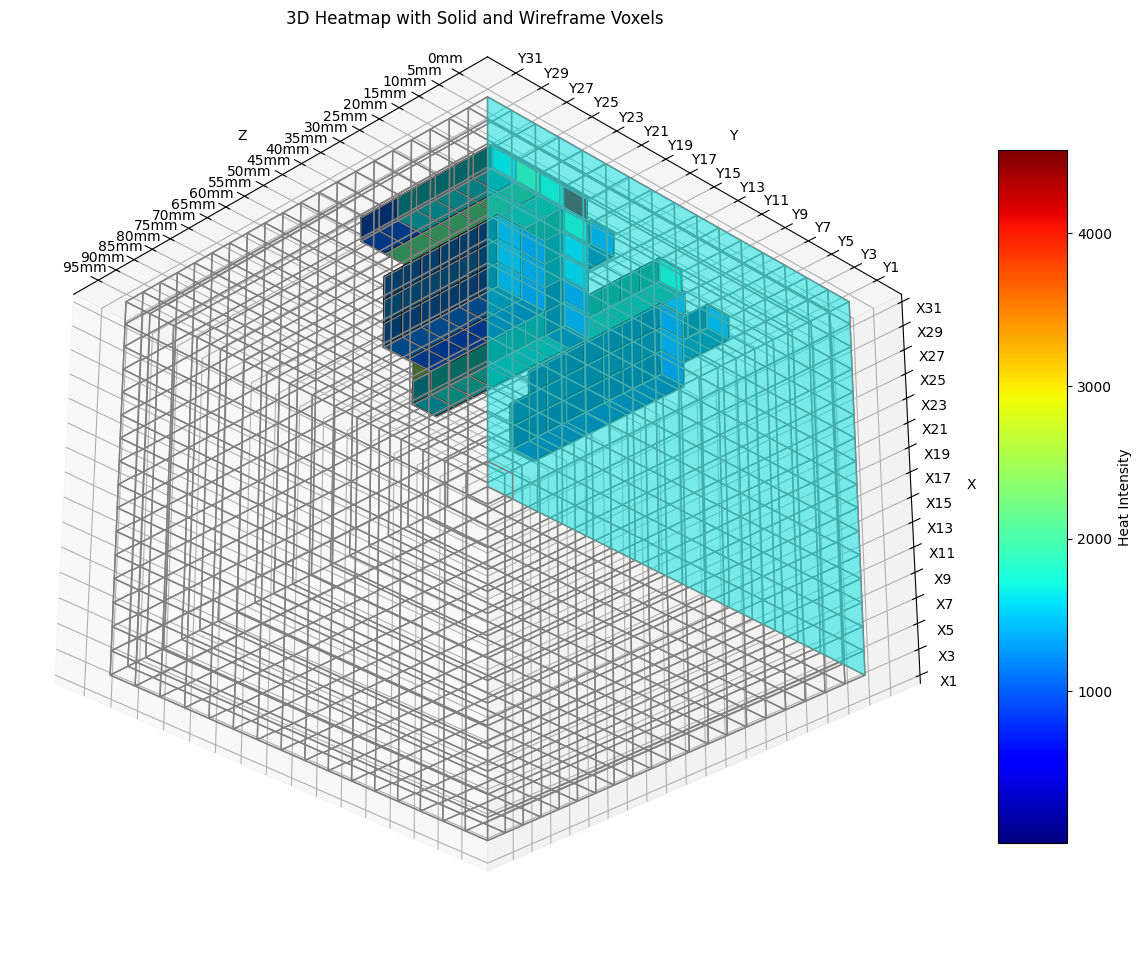

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Create a 3D grid of size 16x16x20
x, y, z = np.indices((20, 16, 16))

# Generate heat values for each voxel
# Assuming you already have your heatmap data in 'data_3D'
heat = np.array(data_3D)

# Define a threshold value below which the blocks will be rendered as wireframe
threshold = 1000

# Create a mask for high-intensity voxels (full solid blocks)
solid_mask = heat >= threshold

# Create a mask for low-intensity voxels (wireframe edges)
wireframe_mask = (heat < threshold) & (heat > 0)  # Between 0 and threshold

# Create a 3D figure
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

# Define the color map for the heatmap
cmap = plt.get_cmap('jet')

# Normalize the heat values to the range 0-1 for color mapping
norm = plt.Normalize(vmin=np.min(heat), vmax=np.max(heat))

# Create the facecolors array based on the solid mask
solid_colors = cmap(norm(heat))

# Set the alpha for solid colors to be fully opaque (alpha=1)
solid_colors[..., -1] = 1.0

scale_factor = 0.5
# Plot the solid voxels (high-intensity blocks)
ax.voxels(solid_mask, facecolors=solid_colors, edgecolor='k')

# Highlight the x-y surface
z_surface = np.arange(0, 17, 1)
y_surface = np.arange(0, 17, 1)
Z_surface, Y_surface = np.meshgrid(z_surface, y_surface)
# Create a surface plot on the x-y plane at z=0
X_surface = np.zeros_like(Z_surface)  # Set Z to zero to plot on the x-y plane
ax.plot_surface(X_surface, Y_surface, Z_surface, color='cyan', alpha=0.5)  # Highlight

# For wireframe voxels, set alpha to 0 (fully transparent) and only keep the edges
wireframe_colors = cmap(norm(heat))
wireframe_colors[..., -1] = 0.0  # Make the faces fully transparent for wireframe

# Plot the wireframe (low-intensity blocks)
ax.voxels(wireframe_mask, facecolors=wireframe_colors, edgecolor='gray')  # Only show edges

# Add a color bar to show the heat intensity scale
mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array(heat)
fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=10, label='Heat Intensity')

# Set labels and title
ax.set_xlabel('Z')
ax.set_ylabel('Y')
ax.set_zlabel('X')
ax.set_title('3D Heatmap with Solid and Wireframe Voxels')

# Customize the tick marks for the x, y, and z axes
z_ticks = np.linspace(0, 16 * scale_factor, 8)  # Adjust tick spacing based on scale factor
y_ticks = np.linspace(0, 16 * scale_factor, 8)
x_ticks = np.linspace(0, 20 * scale_factor, 5)

# Customize the tick marks for the x, y, and z axes
z_ticks = np.linspace(0, 16, 16)  
y_ticks = np.linspace(0, 16, 16)
x_ticks = np.linspace(0, 20, 20)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_zticks(z_ticks)

# Optionally customize tick labels
y_labels = ['Y1', 'Y3', 'Y5', 'Y7', 'Y9', 'Y11', 'Y13', 'Y15', 'Y17', 'Y19', 'Y21', 'Y23', 'Y25', 'Y27', 'Y29', 'Y31'] 
z_labels = ['X1', 'X3', 'X5', 'X7', 'X9', 'X11', 'X13', 'X15', 'X17', 'X19', 'X21', 'X23', 'X25', 'X27', 'X29', 'X31']
x_labels = ['0mm', '5mm', '10mm', '15mm','20mm', '25mm','30mm', '35mm', '40mm', '45mm','50mm','55mm', '60mm', '65mm', '70mm','75mm', '80mm', '85mm', '90mm', '95mm']

ax.set_xticklabels(x_labels)
ax.set_yticklabels(y_labels)
ax.set_zticklabels(z_labels)

# Set the rotation angles (input the desired angles here)
elevation_angle = -30  # Rotation around the x-axis
azimuth_angle = 135    # Rotation around the z-axis

# Apply the rotation
ax.view_init(elev=elevation_angle, azim=azimuth_angle)

# Show the plot
plt.show()


In [12]:
def Plot_3d(tracker_temp, T_average, Real_Time, x, y, z, save_path='./tracker_temperature.png'):
    print("Making plot...")

    fig = plt.figure(figsize=(8, 10))
    ax = fig.add_subplot(111, projection='3d')

    colmap = cm.ScalarMappable(cmap=cm.winter)
    colmap.set_array([-40, -30])

    # reference for cmap. note cmap and c are different!
    # http://matplotlib.org/examples/color/colormaps_reference.html
    ax.scatter(x, y, z, marker='s',s = 200, alpha = 0.9, c=T_TRACKER, cmap='winter', vmin = -40, vmax = -30)
    cb = fig.colorbar(colmap, cax=fig.add_axes([0.05, 0.1, 0.03, 0.8]), label='\N{DEGREE SIGN}C')

    # Convert Unix timestamps to datetime objects and format as strings
    formatted_time = [datetime.utcfromtimestamp(timestamp).strftime("%Y-%m-%d %H:%M:%S.%f") if timestamp is not None else None for timestamp in Real_Time]
    save_time = next((x for x in formatted_time if x is not None), None)

    ax.set_zlim(0, 10)
    ax.set_xlabel('BOOM side')
    ax.set_ylabel('Sun panel side')
    ax.set_zlabel('vertical direction')
    ax.set_title('tracker temperature at ' + str(save_time))

    # Iterate over the indices of T_average
    for i, (temperature, temperature_time) in enumerate(zip(T_average, formatted_time)):
        if temperature is not None:
            # If the value is not None, plot the temperature
            plt.text(0.5, -0.1 - i * 0.03, f'Layer{i} average temperature {temperature:.2f}\N{DEGREE SIGN}C at {temperature_time}\n', ha='center', va='center', transform=ax.transAxes)
            #print(i)
        else:
            # If the value is None, display a message indicating missing data
            plt.text(0.5, -0.1 - i * 0.03, f'Layer{i} data not available\n', ha='center', va='center', transform=ax.transAxes)

    ax.set_zticks([])
    save_path = f"./3D_{save_time}.png"
    # Replace whitespaces and backslashes with underscores
    save_path = save_path.replace(' ', '_').replace(':', '')

    #plt.savefig('./tracker_temperature1.png')
    plt.savefig(save_path)
    plt.show()

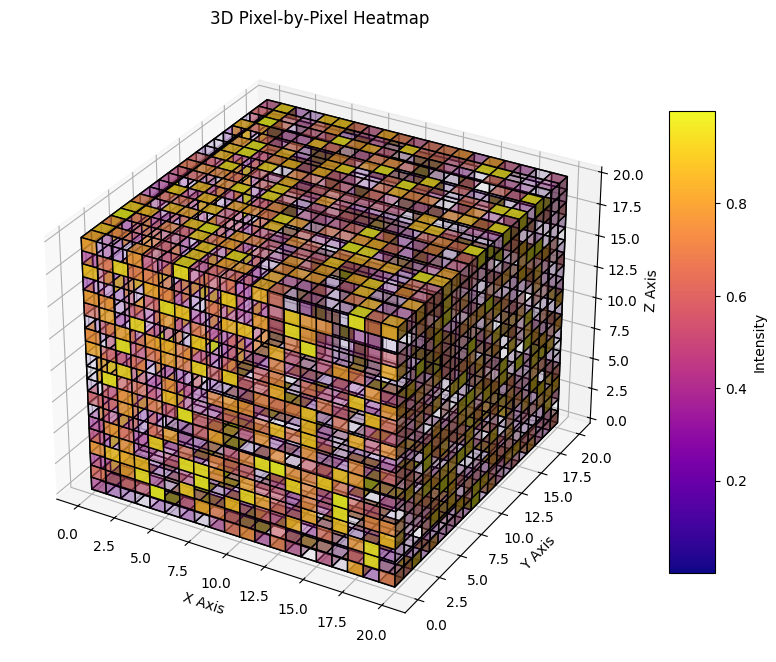

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set the size of the grid
size = 20

# Create a random 3D array to represent voxel intensities
data = np.random.rand(size, size, size)  # Random values between 0 and 1

# Normalize the data to [0, 1] for coloring
norm_data = (data - np.min(data)) / (np.max(data) - np.min(data))

# Create a 3D figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Create the facecolors with transparency based on intensity
# Use the plasma colormap
facecolors = plt.cm.plasma(norm_data)

# Adjust the alpha (transparency) based on normalized values
facecolors[:, :, :, 3] = norm_data  # Set the alpha channel

# Create the voxel plot
ax.voxels(data > 0, facecolors=facecolors, edgecolor='k')  # Only plot voxels where data > 0

# Add a color bar to represent intensity values
mappable = plt.cm.ScalarMappable(cmap='plasma')
mappable.set_array(data)
fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=10, label='Intensity')

# Set labels and title
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Pixel-by-Pixel Heatmap')

# Show the plot
plt.show()


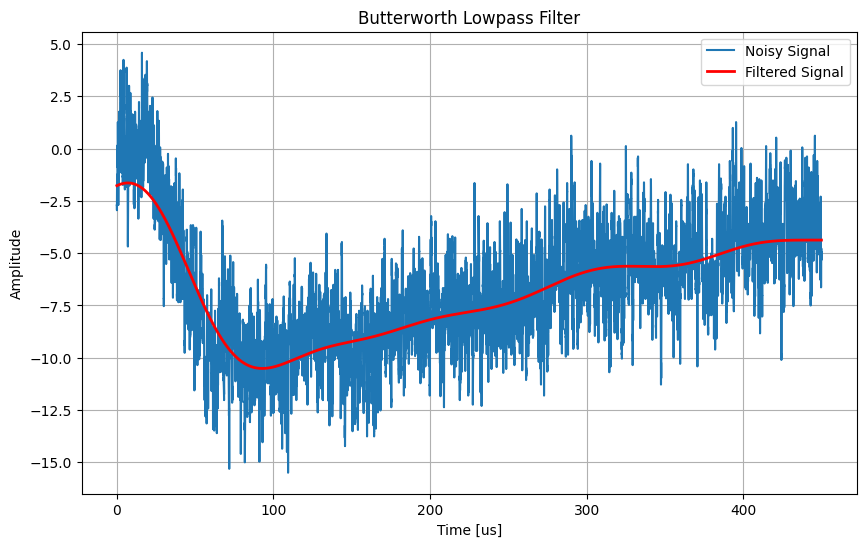

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Butterworth filter design
def digital_butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)  # Use analog=True for analog filter
    return b, a

# Apply the Butterworth filter
def digital_butter_lowpass_filter(data, cutoff, fs, order=5, gain=1.0):
    b, a = digital_butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return gain * y

# Sample data creation
fs = 125000000       # Sample frequency (Hz)
t = np.arange(0, len(temp_corrected_array) / fs, 1 / fs) * 1e6 # Adjust t to match the length of temp_corrected_array

# Filter settings
cutoff = 10000  # Cutoff frequency for the lowpass filter
order = 4    # Filter order

temp_corrected_array = baseline_correction(baseline_array = event_data['ch52'].to_numpy())
#plt.plot(temp_corrected_array)


# Plot the result
#plt.plot(temp_corrected_array)

# Apply filter
filtered_signal = digital_butter_lowpass_filter(temp_corrected_array, cutoff, fs, order, gain=1)

# Plotting the result
plt.figure(figsize=(10, 6))
plt.plot(t, temp_corrected_array, label='Noisy Signal')
plt.plot(t, filtered_signal, label='Filtered Signal', color='red', linewidth=2)
plt.xlabel('Time [us]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.title('Butterworth Lowpass Filter')
plt.show()



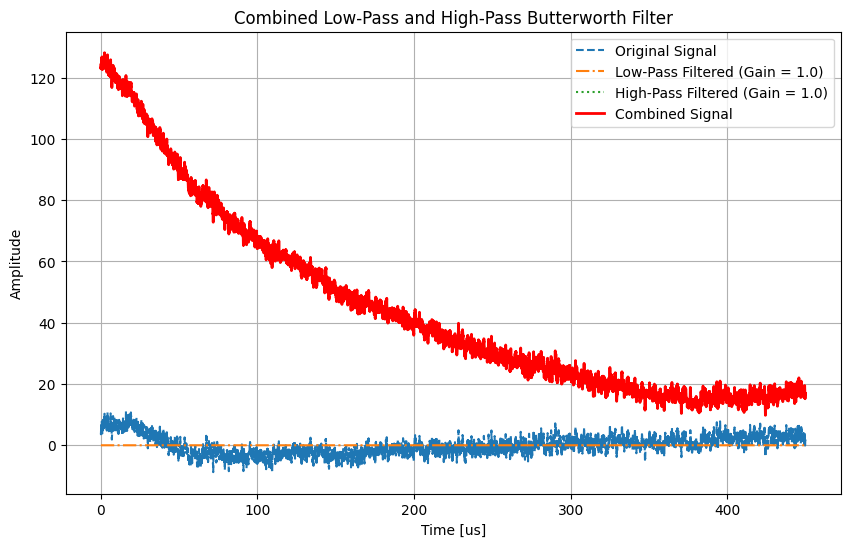

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Butterworth lowpass filter design
def digital_butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

# Butterworth highpass filter design
def digital_butter_highpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

# Apply the Butterworth lowpass filter
def digital_butter_lowpass_filter(data, cutoff, fs, order=5, gain=1.0):
    b, a = digital_butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return gain * y  # Apply the gain to the low-pass filtered signal

# Apply the Butterworth highpass filter
def digital_butter_highpass_filter(data, cutoff, fs, order=5, gain=1.0):
    b, a = digital_butter_highpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return gain * y  # Apply the gain to the high-pass filtered signal

# Sample data creation (assuming event_data is provided)
fs = 125000000  # Sample frequency (Hz)

# Baseline correction
def baseline_correction(baseline_array):
    baseline = np.mean(baseline_array)
    return baseline_array - baseline

# Correct baseline of the signal
temp_corrected_array = baseline_correction(event_data['ch52'].to_numpy())

# Adjust time array to match the length of temp_corrected_array in MICROSECONDS
t = np.arange(0, len(temp_corrected_array) / fs, 1 / fs) * 1e6  # Time in microseconds

# Filter settings
lowpass_cutoff = 120   # Low-pass cutoff frequency (Hz)
highpass_cutoff = 1500  # High-pass cutoff frequency (Hz)
order = 4               # Filter order
lowpass_gain = 1.0      # Gain for low-pass filter
highpass_gain = 1.0     # Gain for high-pass filter

# Apply low-pass and high-pass filters
lowpass_filtered = digital_butter_lowpass_filter(temp_corrected_array, lowpass_cutoff, fs, order, gain=lowpass_gain)
highpass_filtered = digital_butter_highpass_filter(temp_corrected_array, highpass_cutoff, fs, order, gain=highpass_gain)

# Combine both filtered signals (adding low-pass and high-pass signals together)
combined_signal = lowpass_filtered + highpass_filtered

# Plot the results
plt.figure(figsize=(10, 6))

# Original signal
plt.plot(t, temp_corrected_array, label='Original Signal', linestyle='--')

# Low-pass filtered signal
plt.plot(t, lowpass_filtered, label=f'Low-Pass Filtered (Gain = {lowpass_gain})', linestyle='-.')

# High-pass filtered signal
plt.plot(t, highpass_filtered, label=f'High-Pass Filtered (Gain = {highpass_gain})', linestyle=':')

# Combined filtered signal
plt.plot(t, combined_signal, label='Combined Signal', color='red', linewidth=2)

# Plot labels and grid
plt.xlabel('Time [us]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.title('Combined Low-Pass and High-Pass Butterworth Filter')
plt.show()


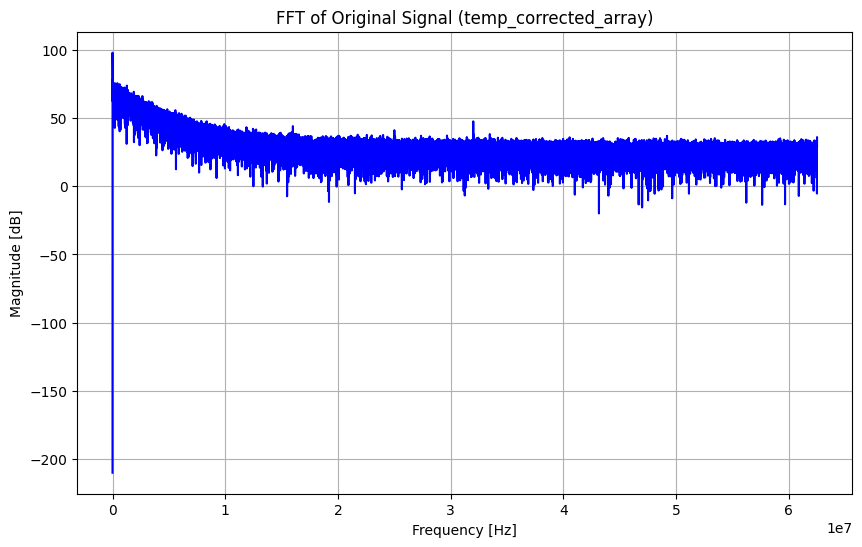

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Compute FFT of the original signal and plot within a certain frequency range on a log scale
def plot_fft_log(signal, fs, freq_range=None):
    N = len(signal)  # Number of samples
    T = 1 / fs       # Sample spacing

    # Perform the FFT
    fft_values = np.fft.fft(signal)
    
    # Compute the frequency bins
    fft_freqs = np.fft.fftfreq(N, T)

    # Take the absolute value of the FFT to get the magnitude spectrum
    fft_magnitude = np.abs(fft_values)
    
    # Only plot the positive frequencies
    positive_freqs = fft_freqs[:N//2]
    positive_magnitude = fft_magnitude[:N//2]

    # Select the frequency range if specified
    if freq_range is not None:
        freq_min, freq_max = freq_range
        freq_mask = (positive_freqs >= freq_min) & (positive_freqs <= freq_max)
        positive_freqs = positive_freqs[freq_mask]
        positive_magnitude = positive_magnitude[freq_mask]
    
    # Plotting the FFT on a log scale
    plt.figure(figsize=(10, 6))
    plt.plot(positive_freqs, 20 * np.log10(positive_magnitude), color='blue')  # Logarithmic scale (dB)
    plt.title('FFT of Original Signal (temp_corrected_array)')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude [dB]')
    #plt.ylim(bottom=0)
    plt.grid()
    plt.show()

# Sample data creation (assuming temp_corrected_array is already provided)
fs = 125000000  # Sample frequency (Hz)

# Define the frequency range to plot (e.g., from 0 to 50,000 Hz)
freq_range = (0, 125000000)  # Set the desired frequency range

# Plot the FFT of the original signal with a specified frequency range and log scale
plot_fft_log(temp_corrected_array, fs, freq_range)


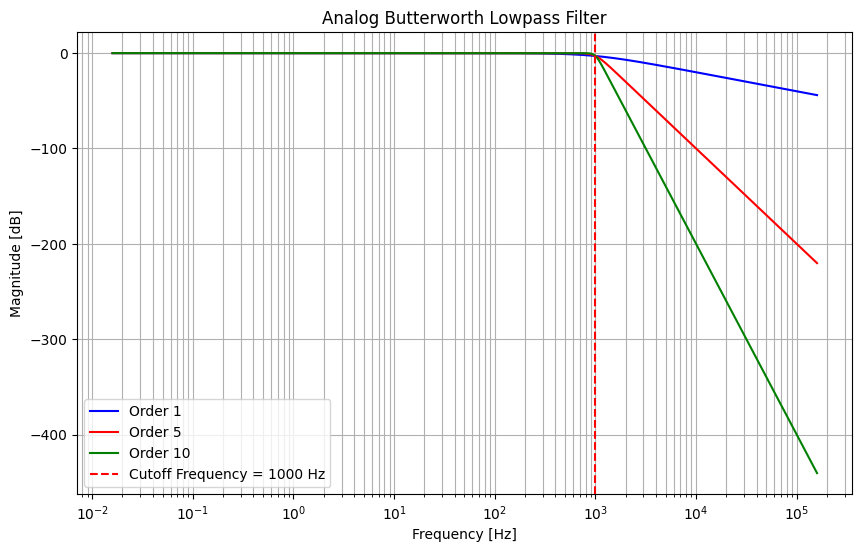

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, freqs

# Analog Butterworth lowpass filter design
def butter_lowpass_analog(cutoff_hz, order=5):
    # Convert cutoff frequency from Hz to radians per second
    cutoff_rad = 2 * np.pi * cutoff_hz  # Convert Hz to rad/s
    b, a = butter(order, cutoff_rad, btype='low', analog=True)  # Analog filter
    return b, a

# Frequency response for the analog filter
def plot_analog_frequency_response(cutoff_hz, order=5, color='blue', label=None):
    # Get the analog filter coefficients
    b, a = butter_lowpass_analog(cutoff_hz, order=order)
    
    # Generate the frequency range for analysis (0 to 10x cutoff in rad/s)
    w, h = freqs(b, a, worN=np.logspace(-1, 6, 1000))  # worN defines the frequency range
    
    # Convert w from rad/s to Hz
    freq_hz = w / (2 * np.pi)  # Convert to Hz

    # Plot the frequency response
    plt.semilogx(freq_hz, 20 * np.log10(abs(h)), color=color, label=label)

# Example usage
cutoff_hz = 1000  # Cutoff frequency in Hz
plt.figure(figsize=(10, 6))

# Plot the frequency response of the analog lowpass filter
plot_analog_frequency_response(cutoff_hz, order=1, label="Order 1")
plot_analog_frequency_response(cutoff_hz, order=5, color='red', label="Order 5")
plot_analog_frequency_response(cutoff_hz, order=10, color='green', label="Order 10")

plt.title('Analog Butterworth Lowpass Filter')
plt.xlabel('Frequency [Hz]')  # Label in Hz
plt.ylabel('Magnitude [dB]')
plt.grid(which='both', axis='both')
plt.axvline(cutoff_hz, color='red', linestyle='--', label=f'Cutoff Frequency = {cutoff_hz} Hz')  # In Hz
plt.legend()
plt.show()


/tmp/ipykernel_2287685/3231900578.py:49: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(freq_hz, 20 * np.log10(abs(h)), color=color, label=label)


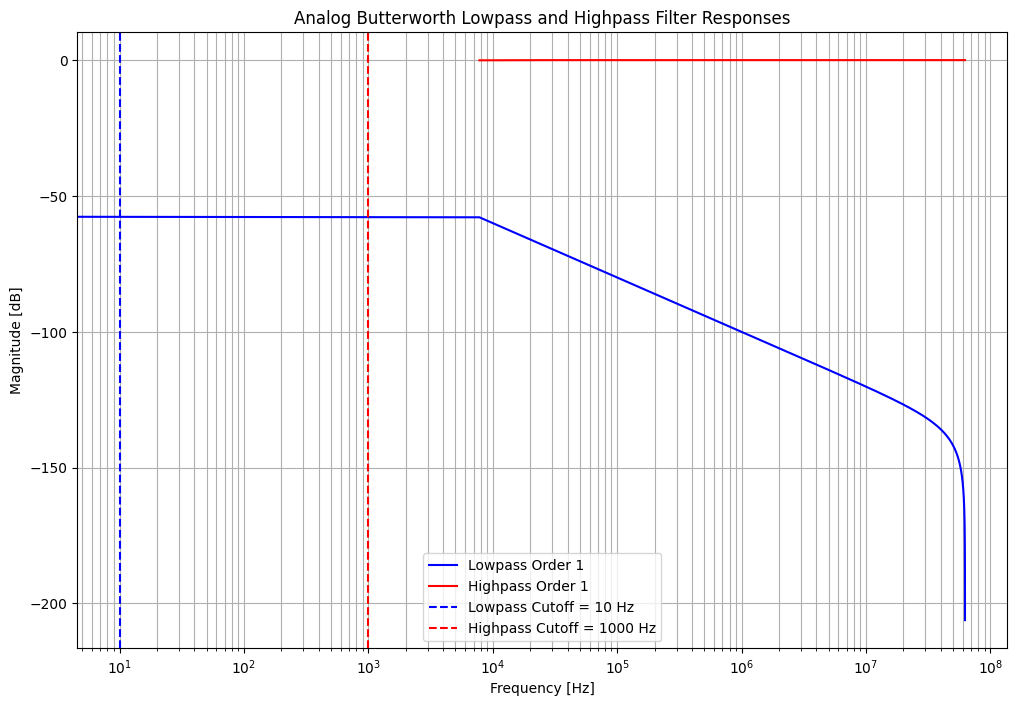

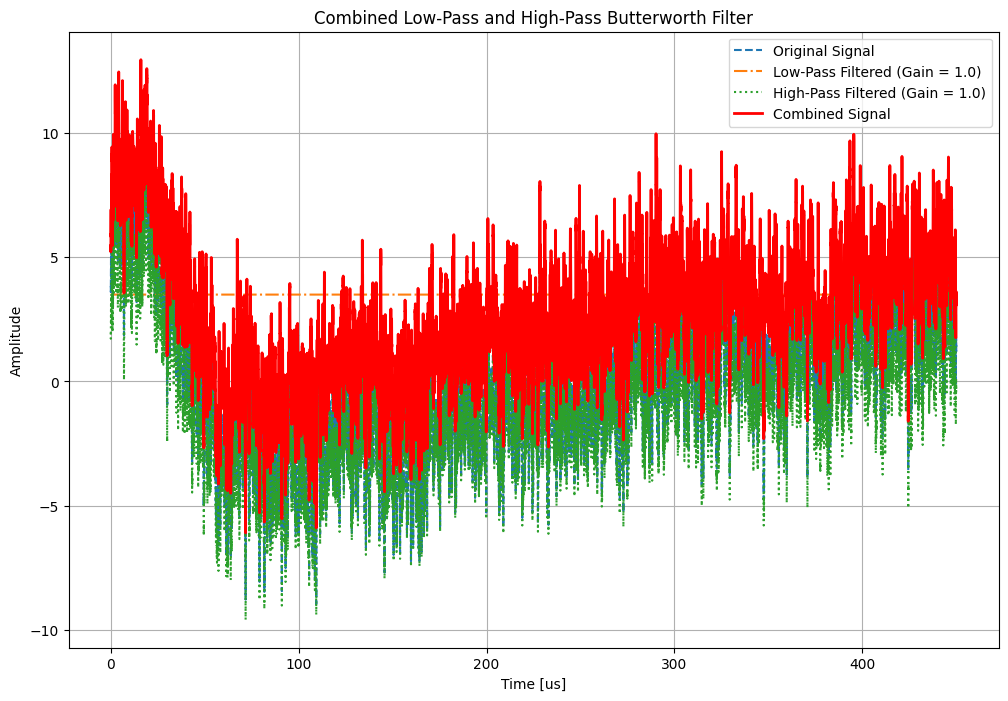

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, freqz


# Analog Butterworth lowpass filter design
def butter_lowpass_digital(cutoff_hz, fs, order=5):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff_hz / nyquist  # Normalize the cutoff frequency
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a


# Analog Butterworth highpass filter design
def butter_highpass_digital(cutoff_hz, fs, order=5):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff_hz / nyquist  # Normalize the cutoff frequency
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a


# Apply the Butterworth lowpass filter
def butter_lowpass_filter_digital(data, cutoff_hz, fs, order=5, gain=1.0):
    b, a = butter_lowpass_digital(cutoff_hz, fs, order=order)
    y = filtfilt(b, a, data)
    return gain * y

# Apply the Butterworth lowpass filter
def butter_highpass_filter_digital(data, cutoff_hz, fs, order=5, gain=1.0):
    b, a = butter_highpass_digital(cutoff_hz, fs, order=order)
    y = filtfilt(b, a, data)
    return gain * y


# Frequency response for the analog filter
def plot_frequency_response(cutoff_hz, order=5, fs=125000000, color='blue', label=None, btype='low'):
    if btype == 'low':
        b, a = butter_lowpass_digital(cutoff_hz, fs=fs, order=order)
    else:
        b, a = butter_highpass_digital(cutoff_hz, fs=fs, order=order)

    # Generate frequency response using freqz
    w, h = freqz(b, a, worN=8000)  # Use a large number of frequency points
    
    # Convert frequency to Hz
    freq_hz = w * fs / (2 * np.pi)

    # Plot the frequency response
    plt.semilogx(freq_hz, 20 * np.log10(abs(h)), color=color, label=label)

# Filter settings
sample_frequency = 125000000    # Sample Frequency
lowpass_cutoff = 10   # Low-pass cutoff frequency (Hz)
highpass_cutoff = 1000  # High-pass cutoff frequency (Hz)
filter_order = 1               # Filter order
lowpass_gain = 1.0      # Gain for low-pass filter
highpass_gain = 1.0     # Gain for high-pass filter

plt.figure(figsize=(12, 8))

# Plot frequency responses
plot_frequency_response(lowpass_cutoff, order=filter_order, fs=sample_frequency, label=f"Lowpass Order {filter_order}", btype='low', color='blue')
plot_frequency_response(highpass_cutoff, order=filter_order, fs=sample_frequency, label=f"Highpass Order {filter_order}", btype='high', color='red')



plt.title('Analog Butterworth Lowpass and Highpass Filter Responses')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.grid(which='both', axis='both')
plt.axvline(lowpass_cutoff, color='blue', linestyle='--', label=f'Lowpass Cutoff = {lowpass_cutoff} Hz')  
plt.axvline(highpass_cutoff, color='red', linestyle='--', label=f'Highpass Cutoff = {highpass_cutoff} Hz')  
plt.legend()
plt.show()

#Apply filter
# Correct baseline of the signal
temp_corrected_array = baseline_correction(event_data['ch52'].to_numpy())

# Adjust time array to match the length of temp_corrected_array in MICROSECONDS
t = np.arange(0, len(temp_corrected_array) / fs, 1 / fs) * 1e6  # Time in microseconds

# Apply low-pass and high-pass filters
lowpass_filtered = butter_lowpass_filter_digital(temp_corrected_array, cutoff_hz=lowpass_cutoff, fs=sample_frequency, order=filter_order, gain=lowpass_gain)
highpass_filtered = butter_highpass_filter_digital(temp_corrected_array, cutoff_hz=highpass_cutoff, fs=sample_frequency, order=filter_order, gain=highpass_gain)

# Combine both filtered signals (adding low-pass and high-pass signals together)
combined_signal = lowpass_filtered + highpass_filtered

# Plot the results
plt.figure(figsize=(12, 8))

# Original signal
plt.plot(t, temp_corrected_array, label='Original Signal', linestyle='--')

# Low-pass filtered signal
plt.plot(t, lowpass_filtered, label=f'Low-Pass Filtered (Gain = {lowpass_gain})', linestyle='-.')

# High-pass filtered signal
plt.plot(t, highpass_filtered, label=f'High-Pass Filtered (Gain = {highpass_gain})', linestyle=':')

# Combined filtered signal
plt.plot(t, combined_signal, label='Combined Signal', color='red', linewidth=2)

# Plot labels and grid
plt.xlabel('Time [us]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.title('Combined Low-Pass and High-Pass Butterworth Filter')
plt.show()


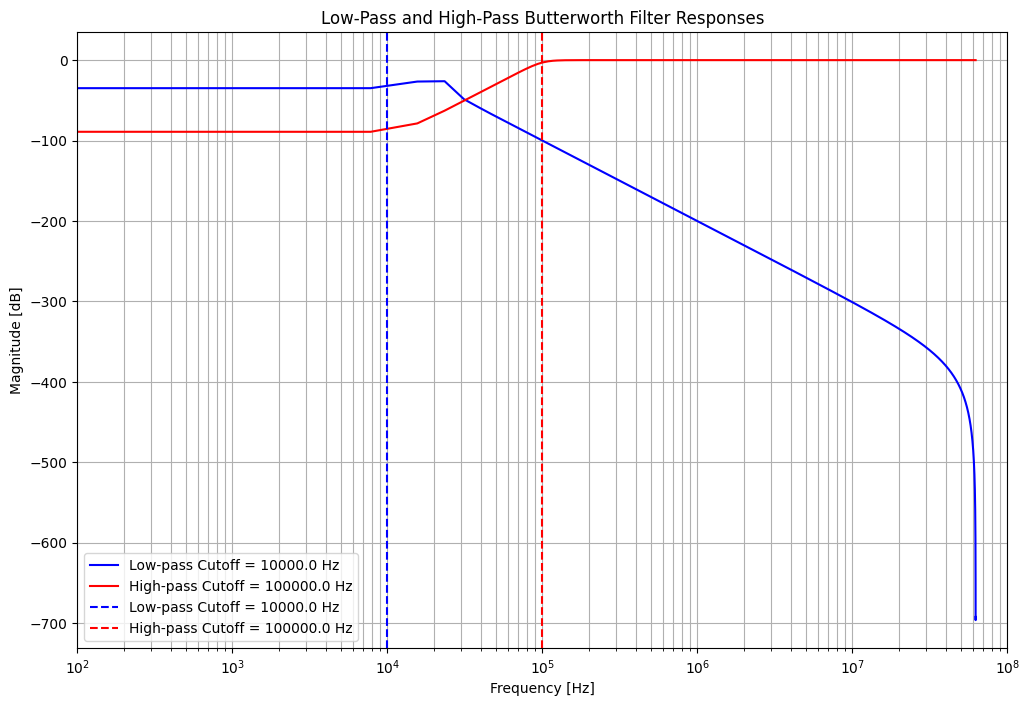

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, freqz

# Digital Butterworth lowpass filter design
def butter_lowpass_digital(cutoff_hz, fs, order=5):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff_hz / nyquist  # Normalize the cutoff frequency
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

# Digital Butterworth highpass filter design
def butter_highpass_digital(cutoff_hz, fs, order=5):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff_hz / nyquist  # Normalize the cutoff frequency
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

# Frequency response plot for both lowpass and highpass filters
def plot_filter_frequency_responses(lowpass_cutoff_hz, highpass_cutoff_hz, fs, order=5):
    # Low-pass filter response
    b_lp, a_lp = butter_lowpass_digital(lowpass_cutoff_hz, fs=fs, order=order)
    w_lp, h_lp = freqz(b_lp, a_lp, worN=8000)
    freq_hz_lp = w_lp * fs / (2 * np.pi)

    # High-pass filter response
    b_hp, a_hp = butter_highpass_digital(highpass_cutoff_hz, fs=fs, order=order)
    w_hp, h_hp = freqz(b_hp, a_hp, worN=8000)
    freq_hz_hp = w_hp * fs / (2 * np.pi)

    # Plot the frequency responses
    plt.figure(figsize=(12, 8))
    plt.semilogx(freq_hz_lp, 20 * np.log10(np.abs(h_lp)), color='blue', label=f'Low-pass Cutoff = {lowpass_cutoff_hz} Hz')
    plt.semilogx(freq_hz_hp, 20 * np.log10(np.abs(h_hp)), color='red', label=f'High-pass Cutoff = {highpass_cutoff_hz} Hz')

    # Configure the plot
    plt.title('Low-Pass and High-Pass Butterworth Filter Responses')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude [dB]')
    plt.grid(which='both', axis='both')
    plt.xlim(1e2, 1e8)  # Set x-axis to cover the range 1 Hz to 1e8 Hz
    plt.axvline(lowpass_cutoff_hz, color='blue', linestyle='--', label=f'Low-pass Cutoff = {lowpass_cutoff_hz} Hz')
    plt.axvline(highpass_cutoff_hz, color='red', linestyle='--', label=f'High-pass Cutoff = {highpass_cutoff_hz} Hz')
    plt.legend()
    plt.show()

# Filter settings
sample_frequency = 125000000  # Sample Frequency in Hz (125 MHz)
lowpass_cutoff = 1e4         # Low-pass cutoff frequency (100 kHz)
highpass_cutoff = 1e5        # High-pass cutoff frequency (3 kHz)
filter_order = 5              # Filter order

# Call the function to plot the frequency responses
plot_filter_frequency_responses(lowpass_cutoff, highpass_cutoff, fs=sample_frequency, order=filter_order)


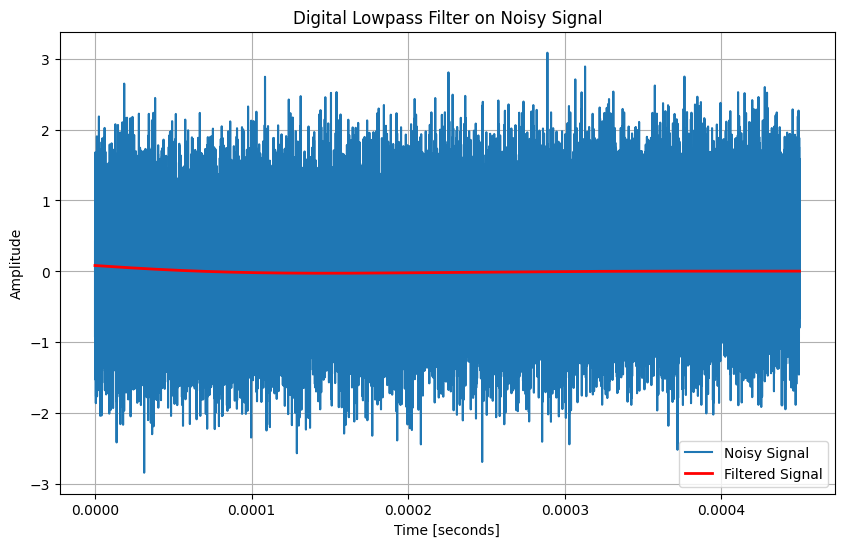

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Create a noisy sine wave signal
def create_noisy_signal(frequency, sample_rate, duration, noise_level=0.5):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    signal = np.sin(2 * np.pi * frequency * t)  # Clean sine wave
    noise = noise_level * np.random.normal(size=t.shape)  # Add Gaussian noise
    noisy_signal = signal + noise
    return t, noisy_signal

# Digital Butterworth lowpass filter design
def butter_lowpass(cutoff_hz, fs, order=5):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff_hz / nyquist  # Normalize the cutoff frequency
    b, a = butter(order, normal_cutoff, btype='low', analog=False)  # Digital filter
    return b, a

# Apply the digital lowpass filter
def apply_lowpass_filter(data, cutoff_hz, fs, order=5):
    b, a = butter_lowpass(cutoff_hz, fs, order=order)
    y = filtfilt(b, a, data)  # Apply zero-phase filter
    return y

# Signal parameters
signal_frequency = 100    # Frequency of the sine wave in Hz
sample_rate = 125000000.0       # Sampling rate in Hz
duration = 0.000450             # Signal duration in seconds
noise_level = 0.7          # Amplitude of the added noise

# Filter parameters
lowpass_cutoff = 1000    # Cutoff frequency of the lowpass filter in Hz
filter_order = 4           # Order of the Butterworth filter

# Create a noisy signal
t, noisy_signal = create_noisy_signal(signal_frequency, sample_rate, duration, noise_level)

# Apply the digital lowpass filter to the noisy signal
filtered_signal = apply_lowpass_filter(noisy_signal, lowpass_cutoff, sample_rate, filter_order)

# Plot the noisy and filtered signal
plt.figure(figsize=(10, 6))
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.plot(t, filtered_signal, color='red', label='Filtered Signal', linewidth=2)
plt.title('Digital Lowpass Filter on Noisy Signal')
plt.xlabel('Time [seconds]')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()


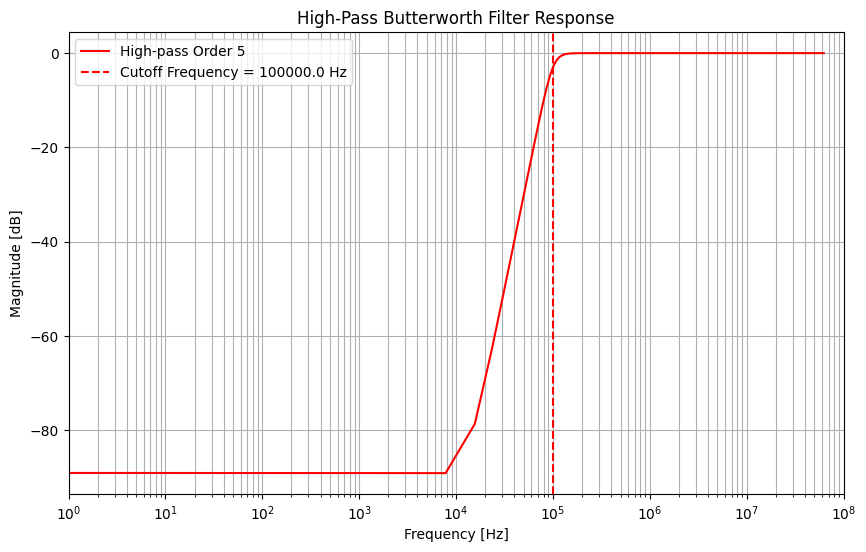

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, freqz

# Digital Butterworth highpass filter design
def butter_highpass_digital(cutoff_hz, fs, order=5):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff_hz / nyquist  # Normalize the cutoff frequency
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

# Frequency response plot for the digital high-pass filter
def plot_highpass_frequency_response(cutoff_hz, fs, order=5):
    b, a = butter_highpass_digital(cutoff_hz, fs=fs, order=order)

    # Generate frequency response using freqz
    w, h = freqz(b, a, worN=8000)  # Use a large number of frequency points
    
    # Convert frequency to Hz
    freq_hz = w * fs / (2 * np.pi)
    
    # Plot the frequency response
    plt.figure(figsize=(10, 6))
    plt.semilogx(freq_hz, 20 * np.log10(np.abs(h)), color='red', label=f'High-pass Order {order}')

    # Configure the plot
    plt.title('High-Pass Butterworth Filter Response')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude [dB]')
    plt.grid(which='both', axis='both')
    plt.xlim(1, 1e8)  # Set x-axis to cover the range 1 Hz to 1e8 Hz
    plt.axvline(cutoff_hz, color='red', linestyle='--', label=f'Cutoff Frequency = {cutoff_hz} Hz')
    plt.legend()
    plt.show()

# Filter settings
sample_frequency = 125000000  # Sample Frequency in Hz (125 MHz)
highpass_cutoff = 1e5         # High-pass cutoff frequency (100 kHz)
filter_order = 5               # Filter order

# Call the function to plot the high-pass frequency response
plot_highpass_frequency_response(highpass_cutoff, fs=sample_frequency, order=filter_order)


(-50.0, 100.0)

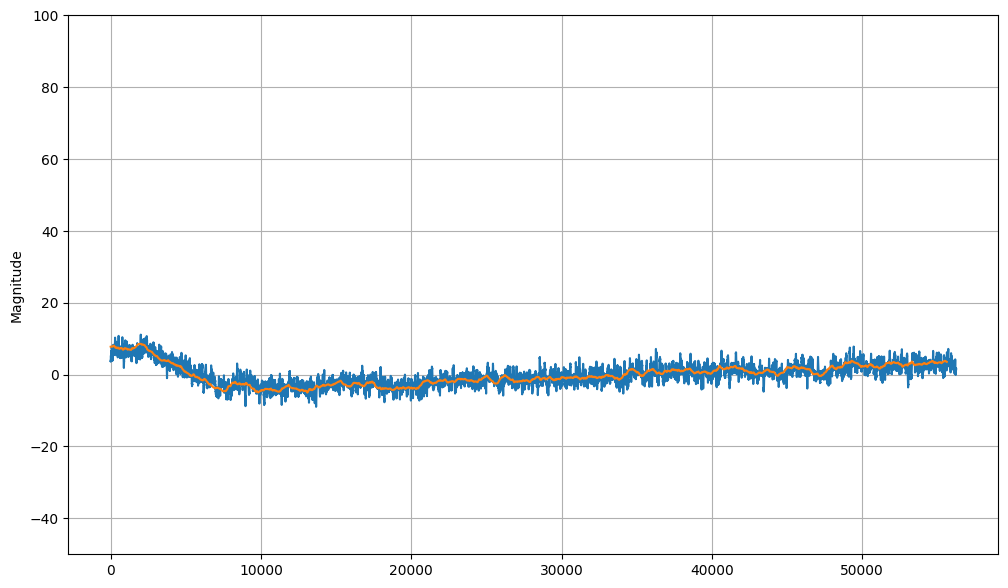

In [22]:
#Self def shaper function trial
def GRAMS_shaper(signal, peaking_time, sampling_rate, gain):
    after_integration = []
    for i in range(len(signal)-int(peaking_time*sampling_rate)):
        after_integration.append(gain*np.average(signal[i:i+int(peaking_time*sampling_rate)])/(peaking_time*sampling_rate))
    return after_integration


fig, ax = plt.subplots(figsize=(12, 7))


temp_corrected_array = baseline_correction(baseline_array = event_data['ch52'].to_numpy())
#plt.plot(temp_corrected_array)

# Plot the result
plt.plot(temp_corrected_array)

after_shaper = GRAMS_shaper(signal=temp_corrected_array, peaking_time=5, sampling_rate=125, gain=700)

plt.plot(after_shaper)
plt.ylabel('Magnitude')
plt.grid()
plt.ylim(-50, 100)